<a href="https://colab.research.google.com/github/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/17_VAEautoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Capítulo 17 – Hands On Machine Learning -  Variational Autoencoders (VAE), GANs, and Diffusion Models**

_Baseado no notebook do Aurélien Géron._

VAE, GANs e Modelos de Difusão são redes neurais que podem gerar instâncias dos dados aprendidos, ou seja são **redes generativas**.



![](https://github.com/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/pics/fig_generativenetworks.png?raw=true)

Fonte da Imagem:[Lil'Log - Lilian Weng](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)

Dessas arquiteturas acima, so os modelos Flow-based e Diffussion conseguem aprender a distribuição dos dados, e todos conseguem gerar dados com caraterísticas similares aos dados de treino.

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/17_autoencoders_gans_and_diffusion_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/17_autoencoders_gans_and_diffusion_models.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

Todo o preambulo de setups do [notebook original](https://github.com/ageron/handson-ml3/blob/main/17_autoencoders_gans_and_diffusion_models.ipynb).

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

**Warning**: the latest TensorFlow versions are based on Keras 3. For chapters 10-15, it wasn't too hard to update the code to support Keras 3, but unfortunately it's much harder for this chapter, in particular adding custom losses using the functional API is not implemented yet. So for this chapter I've had to revert to Keras 2. To do that, I set the `TF_USE_LEGACY_KERAS` environment variable to `"1"` and import the `tf_keras` package. This ensures that `tf.keras` points to `tf_keras`, which is Keras 2.*.

**ainda é necessário fazer assim**

In [3]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

And TensorFlow ≥ 2.8:

In [4]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

In [5]:
tf.__version__

'2.18.0'

(para fazer figuras bonitinhas)

In [6]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/generative` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

(mantive, so por completitude)

In [7]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "generative"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [8]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

In [9]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Variational Autoencoder

In [10]:
import numpy as np
# loads, scales, and splits the fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

A próxima célula de código, com a função que faz a amostragem, (e na seguinte na linha 11, quando é chamada esta função),  são as  que definem essa rede como autoencoder variacional!

Aqui na função sampling (amostragem) é usado o chamado **reparametrization trick** que muda a variavel aleatoria. $ z = \mu(x) + \epsilon  \sigma(x)$

![](https://github.com/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/pics/Reparameterization_Trick.png?raw=true)

Fonte de imagem:[Wikipedia - EugenioTL](https://en.wikipedia.org/wiki/Variational_autoencoder)

In [11]:
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        return tf.random.normal(tf.shape(log_var)) * tf.exp(log_var / 2) + mean

O espaço latente nesse caso é escolhido de dimensão 10 (um vetor de 10 variaveis gaussianas)

In [12]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

codings_size = 10

inputs = tf.keras.layers.Input(shape=[28, 28])
Z = tf.keras.layers.Flatten()(inputs)
Z = tf.keras.layers.Dense(150, activation="relu")(Z)
Z = tf.keras.layers.Dense(100, activation="relu")(Z)
codings_mean = tf.keras.layers.Dense(codings_size)(Z)  # μ
codings_log_var = tf.keras.layers.Dense(codings_size)(Z)  # γ
codings = Sampling()([codings_mean, codings_log_var])
variational_encoder = tf.keras.Model(
    inputs=[inputs], outputs=[codings_mean, codings_log_var, codings])

![](https://github.com/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/pics/Reparameterized_Variational_Autoencoder.png?raw=true)
Fonte da Imagem : [Wikipedia - EugenioTL](https://en.wikipedia.org/wiki/Variational_autoencoder)

In [13]:
decoder_inputs = tf.keras.layers.Input(shape=[codings_size])
x = tf.keras.layers.Dense(100, activation="relu")(decoder_inputs)
x = tf.keras.layers.Dense(150, activation="relu")(x)
x = tf.keras.layers.Dense(28 * 28)(x)
outputs = tf.keras.layers.Reshape([28, 28])(x)
variational_decoder = tf.keras.Model(inputs=[decoder_inputs], outputs=[outputs])

In [14]:
_mean, _logvar, codings = variational_encoder(inputs)
reconstructions = variational_decoder(codings)
variational_ae = tf.keras.Model(inputs=[inputs], outputs=[reconstructions])

Esse termo adicionado chamado _latent loss_ aqui é a divergencia de Kullback-Leibler entre uma distribuição gaussiana (que é a função de distribuição "alvo") e a distribuição real dos ```codings``` (a representação no espaço latente).  Fazer isto "força" a distribuição no espaço latente a se aproximar de uma gaussiana.

In [15]:
latent_loss = -0.5 * tf.reduce_sum(
    1 + codings_log_var - tf.exp(codings_log_var) - tf.square(codings_mean),
    axis=-1)
variational_ae.add_loss(tf.reduce_mean(latent_loss) / 784.)

![](https://github.com/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/pics/KL_divergence.png?raw=true)

Fonte da imagem: [Slides do Andre Sznajder](https://github.com/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/MachineLearning4HEP.pdf)

In [16]:
variational_ae.compile(loss="mse", optimizer=tf.keras.optimizers.Nadam())
history = variational_ae.fit(X_train, X_train, epochs=25, batch_size=128,
                             validation_data=(X_valid, X_valid))

Epoch 1/25
430/430 [==============================] - 9s 9ms/step - loss: 0.0501 - val_loss: 0.0380
Epoch 2/25
430/430 [==============================] - 2s 6ms/step - loss: 0.0361 - val_loss: 0.0355
Epoch 3/25
430/430 [==============================] - 2s 6ms/step - loss: 0.0345 - val_loss: 0.0348
Epoch 4/25
430/430 [==============================] - 2s 6ms/step - loss: 0.0336 - val_loss: 0.0334
Epoch 5/25
430/430 [==============================] - 3s 6ms/step - loss: 0.0330 - val_loss: 0.0332
Epoch 6/25
430/430 [==============================] - 3s 6ms/step - loss: 0.0327 - val_loss: 0.0327
Epoch 7/25
430/430 [==============================] - 2s 6ms/step - loss: 0.0323 - val_loss: 0.0324
Epoch 8/25
430/430 [==============================] - 2s 6ms/step - loss: 0.0321 - val_loss: 0.0322
Epoch 9/25
430/430 [==============================] - 2s 6ms/step - loss: 0.0319 - val_loss: 0.0325
Epoch 10/25
430/430 [==============================] - 3s 7ms/step - loss: 0.0318 - val_loss: 0.0320

In [ ]:
from keras.utils import plot_model
plot_mode(variational_ae, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [17]:
variational_ae.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 28, 28)]             0         []                            
                                                                                                  
 model (Functional)          [(None, 10),                 134870    ['input_1[0][0]']             
                              (None, 10),                                                         
                              (None, 10)]                                                         
                                                                                                  
 model_1 (Functional)        (None, 28, 28)               134634    ['model[0][2]']               
                                                                                            

In [18]:
def plot_reconstructions(model, images=X_valid, n_images=10):
    reconstructions = np.clip(model.predict(images[:n_images]), 0, 1)
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plt.imshow(images[image_index], cmap="binary")
        plt.axis("off")
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plt.imshow(reconstructions[image_index], cmap="binary")
        plt.axis("off")

1/1 [==============================] - 0s 146ms/step


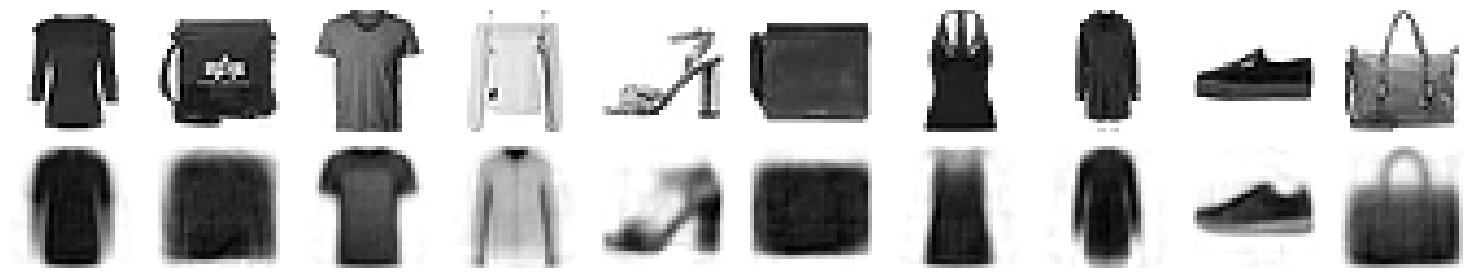

In [19]:
plot_reconstructions(variational_ae)
save_fig("variational")
plt.show()

## Generate Fashion Images

Agora a "mágica" dessa rede é que podemos gerar novas imagens a partir de vetores quaisquer do espaço latente.

Aqui vamos gerar 3x7 = 21 vetores  aleatorios de 10 elementos (codings) e vamos chamar o decoder da rede para gerar imagens a partir desses vetores.

![](https://github.com/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/pics/Latentspace_FFleuret.png?raw=true)
Fonte da imagem: [François Fleuret UNIGE](https://fleuret.org/dlc/)

In [20]:
tf.random.set_seed(400)  # extra code – ensures reproducibility on CPU

codings = tf.random.normal(shape=[3 * 7, codings_size])
images = variational_decoder(codings).numpy()

Vamos dar uma olhada

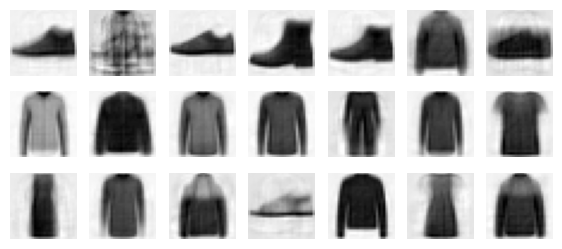

In [21]:
# extra code – this cells generates and saves Figure 17-12

def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

plot_multiple_images(images, 7)
save_fig("vae_generated_images_plot", tight_layout=False)
plt.show()

In [25]:
## o que menos parece imagem real é o segundo elemento
print(codings[1])


tf.Tensor(
[-0.6267616   0.33461115  0.15572646 -0.04436037  1.7144324  -0.08964873
  0.26223934 -0.40015206  0.8481636  -0.4950906 ], shape=(10,), dtype=float32)


Podemos ver como no espaço latente podemos fazer umainterpolação "semántica" entre imagens (transicionar entre uma imagem e outra com "sentidos" similares)

In [52]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

codings = np.zeros([10, codings_size])
codings[:,0] = np.linspace(-2.5, 2.5, 10)  # testar qual eixo se ve melhor
#codings[:,6] = np.linspace(-2.5, 2.5, 10)
#codings[:,5] = np.linspace(-2.5, 2.5, 10)
codings = tf.constant(codings)
images = variational_decoder(codings).numpy()

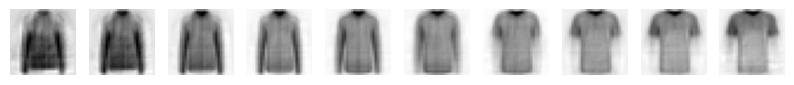

In [53]:
# extra code – this cell generates and saves Figure 17–13
plot_multiple_images(images)
save_fig("semantic_interpolation_plot", tight_layout=False)
plt.show()

Posso tambem escolher uma coisa arbitrária!

In [51]:
arbitrary_coding=tf.constant([-10.,1.,2.,-1.,2.,0.,5.,5.,-1. ,10. ])
arbitrary_image=variational_decoder(arbitrary_coding[None]).numpy()

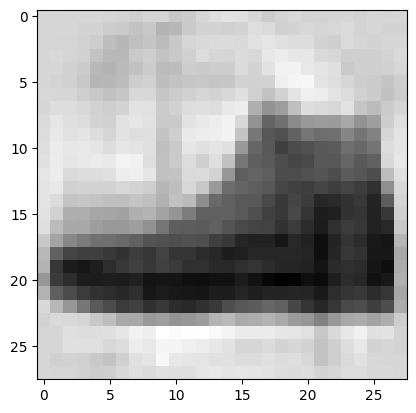

In [45]:
plt.imshow(arbitrary_image.squeeze(axis=0),cmap="binary")
#plt.show()

Para a próxima, vamos ver as outras redes generativas : GANs (e seus sabores), Diffusion, Flow-based.
